# Sequential Diagnosis Environment

**Goal.** Build the interactive environment every later stage plugs into: replay a patient
case as a turn-based diagnostic encounter where an agent must *ask*, *test*, and *commit* a
diagnosis under realistic information and cost constraints - sourced from **structured EHR
data** rather than a narrative case report.

## Pipeline

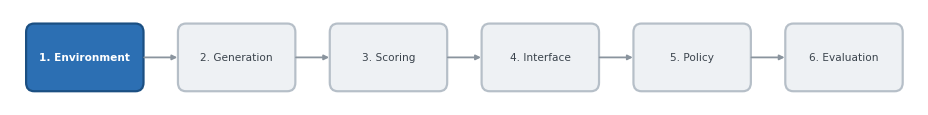

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
from shared.diagrams import draw_pipeline, draw_sdbench_loop
draw_pipeline(active='environment');

## Prior work and limitations

- **Nori et al. 2025, *Sequential Diagnosis with Language Models* (SDBench / MAI-DxO).**
  The framework we replicate: a Gatekeeper that reveals findings only on request, a 3-action
  loop (ask / test / diagnose), and cost as a first-class metric.
- **Johnson et al. 2023, *MIMIC-IV*.** The structured EHR dataset whose schema we imitate
  (labevents, microbiologyevents, radiology, diagnoses_icd) and adapt to later.
- **Jiang et al. 2025, *MedAgentBench*.** A virtual EHR environment for LLM agents -
  evidence that EHR-grounded agent benchmarks are a live, needed direction.
- **Tu et al. 2025, *AMIE*.** Interactive, multi-turn diagnostic dialogue, motivating an
  environment that scores *process*, not just a final answer.

![paper figure](../shared/paper_figs/fig2_sdbench.png)

*Figure: the sequential-diagnosis loop (Nori et al. 2025).*

## Approach

SDBench is built over **304 hand-curated NEJM narrative cases**. We keep its mechanics but
source findings from a **structured, MIMIC-IV-shaped record**. Why this matters:

- **Scale & realism:** EHR data is abundant and reflects real test ordering, reference
  ranges, microbiology, and *real cost* - not a few hundred curated write-ups.
- **No hindsight narrative:** structured fields avoid the spoilers and tidy framing baked
  into published case reports.
- **Enables the downstream question:** real ordering/cost data is what makes the *when to
  alert* problem (Stages 03-05) meaningful.

> Real MIMIC-IV needs PhysioNet credentialing + a DUA, so these are small synthetic
> stand-ins shaped like the real tables; swapping in real MIMIC is a loader change.

## Mechanism

**Input** (per turn): one action - `ask_question(text)`, `order_test(name)`, or
`diagnose(text)`.
**Output:** the Gatekeeper returns a finding (or a synthesized normal result, or a refusal),
adds its cost, and on `diagnose` the Judge scores the answer against the ICD ground truth.
The Gatekeeper (highlighted) is the part this notebook builds.

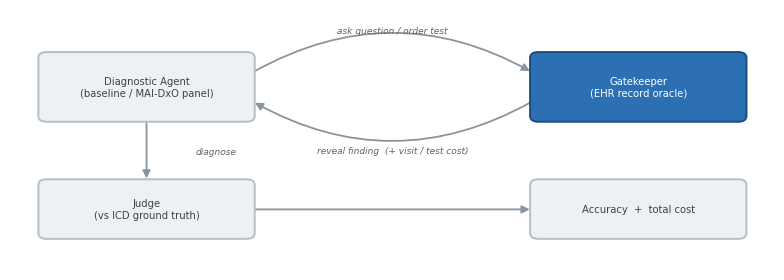

In [2]:
draw_sdbench_loop(highlight='gatekeeper');

## Walkthrough
### 1. The underlying record (MIMIC-IV-shaped)
*Expected output:* a patient, the opening abstract, ICD ground truth, the orderable tests,
and one example lab row. The agent never sees this directly - only the Gatekeeper does.

In [3]:
from shared.toy_data import load_case
case = load_case('PE-2180')
print('patient :', case.patient)
print('abstract:', case.abstract)
for d in case.diagnoses_icd:
    print(f'  ground-truth ICD seq {d.seq_num}: {d.icd_code} - {d.long_title}')
print('orderable tests:', list(case.panels))
print('example lab row:', case.labevents['D-Dimer'])

patient : Patient(subject_id=10002180, gender='F', anchor_age=52)
abstract: A 52-year-old woman presents with sudden pleuritic chest pain and dyspnea three days after a long-haul flight.
  ground-truth ICD seq 1: I2699 - Other pulmonary embolism without acute cor pulmonale
orderable tests: ['CBC', 'D-Dimer', 'Troponin', 'BMP', 'CT pulmonary angiogram', 'Chest radiograph']
example lab row: LabEvent(label='D-Dimer', category='Chemistry', value='3.42', valueuom='ug/mL FEU', ref_lower=0.0, ref_upper=0.5, flag='H')


### 2. Step through an encounter
*Expected input:* a question, then two test orders. *Expected output:* each call returns a
finding and a cost; the $300 visit is charged once for the question burst.

In [4]:
from demo_environment import SequentialDiagnosisEnv
env = SequentialDiagnosisEnv(case=case)
print(env.observation(), '\n')
for step in [
    env.ask_question('What are the risk factors and when did symptoms start?'),
    env.order_test('D-Dimer'),
    env.order_test('CT pulmonary angiogram'),
]:
    print(f'[turn {step.turn}] {step.action.split(":")[0]:<8} +${step.cost:>4.0f}')
    for line in step.response.splitlines():
        print('   ', line)

Case abstract: A 52-year-old woman presents with sudden pleuritic chest pain and dyspnea three days after a long-haul flight.
Findings revealed so far: (none)
Cumulative cost: $0 

[turn 1] ask      +$ 300
    Recent 11-hour flight; on combined oral contraceptives; no prior clots.
[turn 2] order    +$  40
    D-Dimer:
      D-Dimer: 3.42 ug/mL FEU (ref 0.0-0.5 ug/mL FEU) [H]
[turn 3] order    +$ 500
    CT pulmonary angiogram (CT): Filling defect in the right lower lobe segmental pulmonary artery consistent with acute pulmonary embolism. Right heart strain not present.


### 3. The Gatekeeper's two safeguards
*Expected output:* an off-record test returns a plausible **normal** result (so absence is
not a clue); a vague request is **refused**.

In [5]:
print('off-record ->', env.gatekeeper.order_test('Lyme serology'))
print('vague      ->', env.gatekeeper.order_test('labs'))

off-record -> ('Lyme serology: within normal limits.', 50.0, False)
vague      -> ("[Gatekeeper] 'labs' is too non-specific; please order a named test.", 0.0, False)


### 4. Commit a diagnosis and read the Judge
*Expected output:* a CORRECT/INCORRECT verdict vs the ICD ground truth, plus the running cost.
(The Judge here is a transparent token match standing in for SDBench's 5-point LLM rubric.)

In [6]:
step = env.diagnose('Acute pulmonary embolism')
print(step.response)
print(f'\nturns={env.turn}  total_cost=${env.total_cost:.0f}  '
      f'key_tests_ordered={case.confirmable_by(env.ordered)}')

Judge: CORRECT | matched tokens=['embolism', 'pulmonary'] vs principal dx='Other pulmonary embolism without acute cor pulmonale'

turns=4  total_cost=$840  key_tests_ordered=True


**Next:** Notebook 02 replaces this hand-scripted trajectory with a model - first the
paper's baseline prompt, then the MAI-DxO virtual panel.